# Healthcare Predictive Analytics — Disease Prediction

### Machine Learning Using Random Forest

This project develops a basic predictive model to predict diseases from historical healthcare data using Python and machine learning.

In [1]:
import pandas as pd

df = pd.read_csv('/content/Synthetic_Medical_Dataset_v2.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (15000, 36)

Column names:
['Patient_ID', 'Age', 'Gender', 'Blood_Group', 'Weight_kg', 'Has_Fever', 'Has_Cough', 'Has_Fatigue', 'Has_Pain', 'Has_Hypertension', 'Has_Diabetes', 'Temperature_C', 'Heart_Rate', 'BP_Systolic', 'WBC_Count', 'Glucose_Level', 'Predicted_Disease', 'Disease_Causes', 'Medicine_1', 'Dosage_1', 'Frequency_1', 'Duration_1', 'Instructions_1', 'Medicine_2', 'Dosage_2', 'Frequency_2', 'Duration_2', 'Instructions_2', 'Medicine_3', 'Dosage_3', 'Frequency_3', 'Duration_3', 'Instructions_3', 'Personalized_Health_Tips', 'Polypharmacy_Risk', 'Polypharmacy_Recommendation']

First 5 rows:


,Patient_ID,Age,Gender,Blood_Group,Weight_kg,Has_Fever,Has_Cough,Has_Fatigue,Has_Pain,Has_Hypertension,...,Duration_2,Instructions_2,Medicine_3,Dosage_3,Frequency_3,Duration_3,Instructions_3,Personalized_Health_Tips,Polypharmacy_Risk,Polypharmacy_Recommendation
0,1,61,Male,B+,92.9,0,0,0,1,0,...,As needed,Apply to affected joint.,NaN,NaN,NaN,NaN,NaN,"Maintain healthy weight, low-impact exercise (...",Low,Monitor liver function with high-dose acetamin...
1,2,45,Male,AB+,82.7,0,0,1,0,1,...,Short-term only,"For panic attacks, use sparingly due to depend...",NaN,NaN,NaN,NaN,NaN,"Cognitive behavioral therapy (CBT), stress man...",Medium,Monitor for side effects of SSRI. Caution with...
2,3,23,Male,B+,64.0,0,0,1,1,0,...,As needed,Apply to affected joint.,NaN,NaN,NaN,NaN,NaN,"Maintain healthy weight, low-impact exercise (...",Low,Monitor liver function with high-dose acetamin...
3,4,49,Female,B-,77.1,1,0,0,1,0,...,As needed,For fever/pain relief.,NaN,NaN,NaN,NaN,NaN,"Get annual flu shot, rest, fluids, avoid contact.",Medium,"Review potential interactions, especially Osel..."
4,5,44,Female,O+,99.3,0,0,1,0,0,...,Short-term only,"For panic attacks, use sparingly due to depend...",NaN,NaN,NaN,NaN,NaN,"Cognitive behavioral therapy (CBT), stress man...",Medium,Monitor for side effects of SSRI. Caution with...


In [2]:
print("Number of disease categories:", df['Predicted_Disease'].nunique())

print("\nDisease distribution:")
print(df['Predicted_Disease'].value_counts())

Number of disease categories: 13

Disease distribution:
Predicted_Disease
Anxiety Disorder           1222
Diabetes Type 2            1195
Urinary Tract Infection    1195
Influenza                  1182
Bacterial Pneumonia        1179
GERD                       1174
Hypothyroidism             1143
Hypertension               1143
Asthma Exacerbation        1138
Osteoarthritis             1132
Common Cold                1121
Migraine                   1092
Healthy                    1084
Name: count, dtype: int64


In [3]:
features = [
    'Age',
    'Weight_kg',
    'Has_Fever',
    'Has_Cough',
    'Has_Fatigue',
    'Has_Pain',
    'Has_Hypertension',
    'Has_Diabetes',
    'Temperature_C',
    'Heart_Rate',
    'BP_Systolic',
    'WBC_Count',
    'Glucose_Level'
]

print("Number of input features:", len(features))
print("\nInput features:")
for feature in features:
    print("-", feature)

Number of input features: 13

Input features:
- Age
- Weight_kg
- Has_Fever
- Has_Cough
- Has_Fatigue
- Has_Pain
- Has_Hypertension
- Has_Diabetes
- Temperature_C
- Heart_Rate
- BP_Systolic
- WBC_Count
- Glucose_Level


In [4]:
X = df[features]
y = df['Predicted_Disease']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

X shape: (15000, 13)
y shape: (15000,)

Missing values in X:
0

Missing values in y:
0


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12000, 13)
Testing data: (3000, 13)


In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [7]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions completed!
Number of predictions: 3000

First 10 predictions:
['Bacterial Pneumonia' 'Urinary Tract Infection' 'Influenza'
 'Hypertension' 'Hypothyroidism' 'Osteoarthritis' 'GERD' 'Diabetes Type 2'
 'Influenza' 'Asthma Exacerbation']


In [8]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 70.43%

Classification Report:
                         precision    recall  f1-score   support

       Anxiety Disorder       0.67      0.74      0.70       244
    Asthma Exacerbation       0.75      0.73      0.74       228
    Bacterial Pneumonia       0.92      0.96      0.94       236
            Common Cold       0.61      0.54      0.57       224
        Diabetes Type 2       0.98      0.98      0.98       239
                   GERD       0.45      0.38      0.41       235
                Healthy       0.69      0.73      0.71       217
           Hypertension       0.89      0.91      0.90       229
         Hypothyroidism       0.65      0.72      0.68       229
              Influenza       0.81      0.78      0.79       236
               Migraine       0.40      0.37      0.39       218
         Osteoarthritis       0.50      0.52      0.51       226
Urinary Tract Infection       0.74      0.75      0.74       239

               accuracy                  

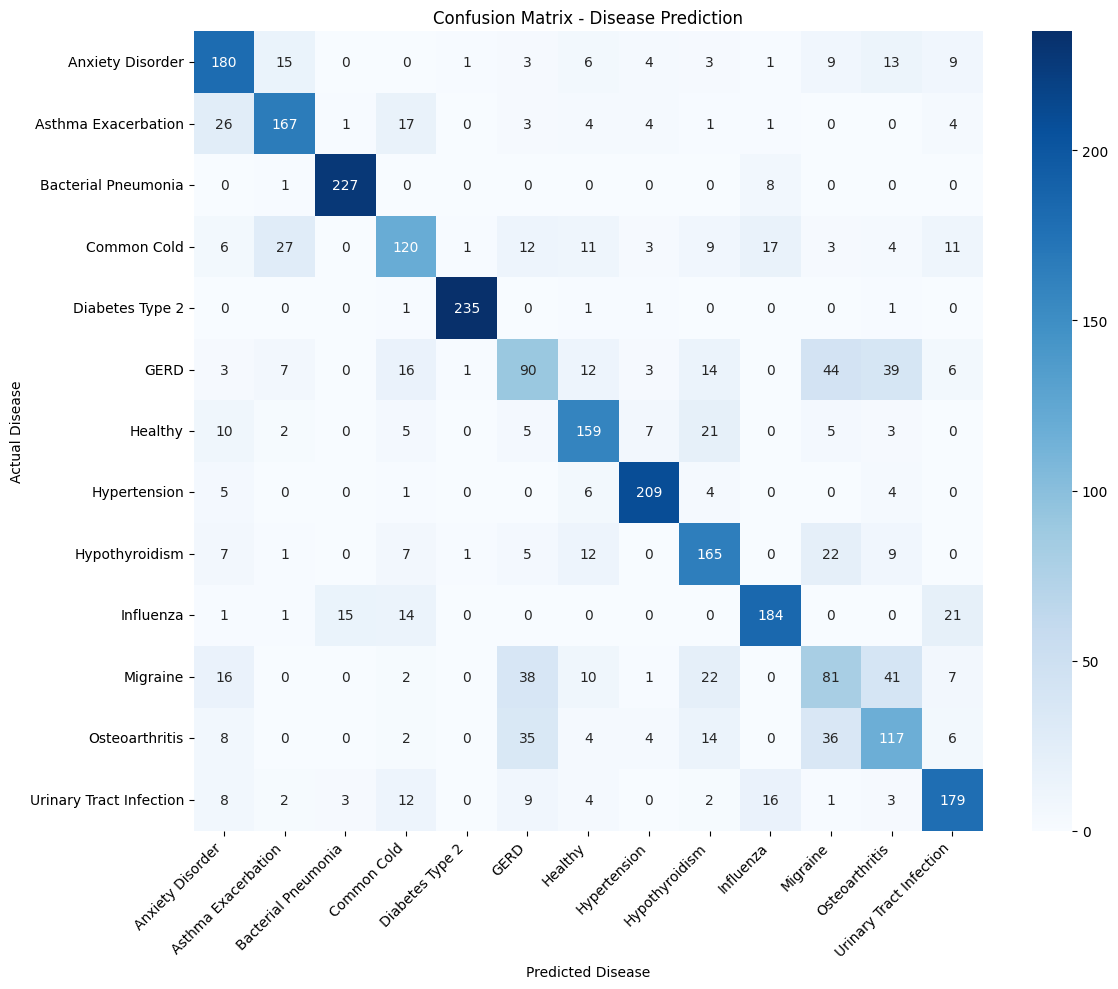

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title('Confusion Matrix - Disease Prediction')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
11         WBC_Count    0.138286
9         Heart_Rate    0.133545
12     Glucose_Level    0.124322
8      Temperature_C    0.123698
10       BP_Systolic    0.111076
1          Weight_kg    0.069877
0                Age    0.064332
3          Has_Cough    0.061045
5           Has_Pain    0.048306
4        Has_Fatigue    0.036180
2          Has_Fever    0.031867
6   Has_Hypertension    0.030874
7       Has_Diabetes    0.026593


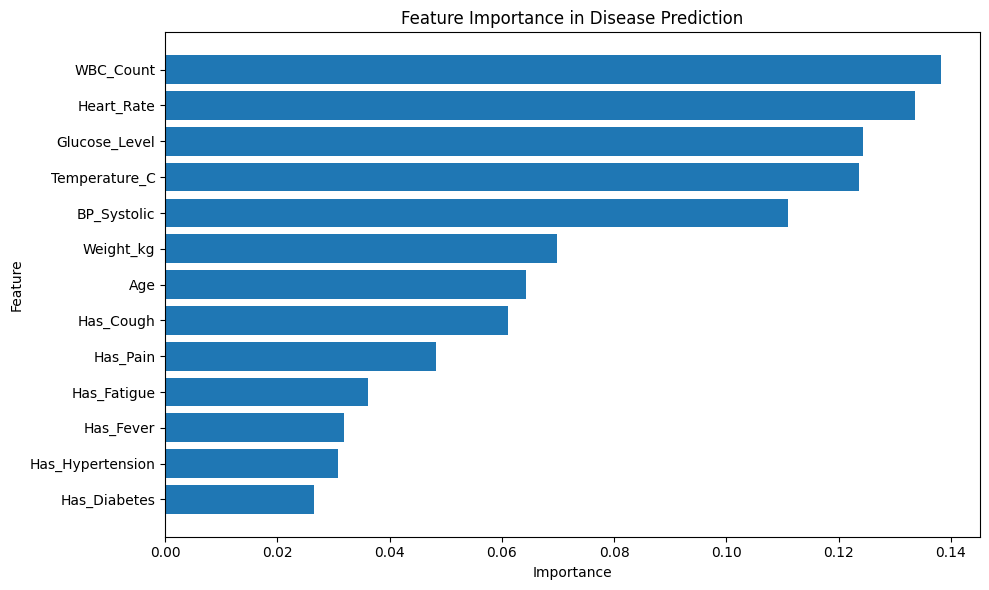

In [11]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Disease Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

evaluation_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-Score'
    ],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
    ]
})

evaluation_summary['Score'] = evaluation_summary['Score'].round(4)

display(evaluation_summary)

,Metric,Score
0,Accuracy,0.7043
1,Macro Precision,0.6968
2,Macro Recall,0.7014
3,Macro F1-Score,0.6982


# Healthcare Predictive Analytics

## Objective
The objective of this project is to develop a basic machine learning model for predicting diseases using historical healthcare data.

## Dataset
The dataset contains 15,000 patient records with 36 healthcare-related variables. The target variable is `Predicted_Disease`, which contains 13 disease categories.

## Methodology
- Selected 13 patient-related features including age, weight, symptoms, temperature, heart rate, blood pressure, WBC count, and glucose level.
- Checked the dataset for missing values.
- Split the data into 80% training and 20% testing sets.
- Used a Random Forest Classifier for disease prediction.
- Evaluated the model using accuracy, precision, recall, F1-score, and a confusion matrix.
- Analyzed feature importance to identify the variables contributing most to the model's predictions.

## Results
The Random Forest model achieved an accuracy of 70.43% on the test dataset.

The macro-average precision was 69.68%, macro-average recall was 70.14%, and macro-average F1-score was 69.82%.

The most important features identified by the model were WBC count, heart rate, glucose level, temperature, and systolic blood pressure.

## Conclusion
The project demonstrates how machine learning can be applied to historical healthcare data for basic disease prediction. The model achieved moderate predictive performance and showed that clinical measurements such as WBC count, heart rate, glucose level, temperature, and blood pressure were important for prediction.

This project is intended for educational and analytical purposes and should not be used as a substitute for professional medical diagnosis.